<a href="https://colab.research.google.com/github/MilindLate/Subsystem-data/blob/main/ISHM_LiquidPropulsion_FaultDetection_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Liquid Propulsion — Fault/Anomaly Detection (ISHM Project)

**Subsystem model 1 of 8.** Hybrid architecture per project plan:
1. **tsfresh + Random Forest** — data-driven classifier over engineered features (statistical/spectral/temporal), same methodology as the DRDO/MVSR reference paper this project is built on.
2. **Physics-based residual detector** — an independent, explainable check: expected chamber pressure (from a design throttle curve) vs. actual, flagged when the residual exceeds a threshold.
3. **Hybrid fusion** — combine both so a fault is flagged if *either* detector fires, giving you redundancy the way your project's AI Design Principles require (never a single model per subsystem).

This notebook is self-contained: it regenerates the hybrid real+synthetic dataset from scratch (real NASA/IMS bearing data + real NASA C-MAPSS degradation trends, both pulled live from GitHub — Colab has full internet access, unlike the sandbox this was developed in), extracts features, trains, evaluates, visualizes, and packages the trained model for download.

**Runtime:** CPU is fine. GPU not required for this subsystem's model (Random Forest). Expect 5-15 minutes end-to-end depending on `N_PER_CLASS`.


## 0. Setup — install dependencies

In [ ]:

!pip install -q tsfresh scikit-learn joblib seaborn matplotlib pandas numpy scipy
print("Dependencies installed.")


Dependencies installed.



## 1. Fetch real data (Colab has internet — this sandbox this was built in did not)

Two real datasets, each covering a different real failure mechanism for this subsystem:
- **NASA/IMS + Case Western bearing vibration** → turbopump bearing wear analog
- **NASA C-MAPSS turbofan degradation** → progressive multi-sensor degradation trend-shape donor (a jet engine, not a rocket engine — used for the *shape* of real degradation, not physical values; see the Liquid Propulsion telemetry dictionary for the full rationale)

If either clone fails (rate limits, network hiccup), the generator below automatically falls back to pure-synthetic for that fault class — the notebook still runs end-to-end either way.


In [ ]:

import os

# Real bearing data (NASA/IMS + Case Western) -- ~6.3GB full repo, we only need 1st_test
os.makedirs("real_data", exist_ok=True)
if not os.path.exists("real_data/bearing_dataset"):
    !git clone --depth 1 https://github.com/vibraneur-capstone/dataset.git real_data/bearing_dataset
BEARING_DIR = "real_data/bearing_dataset/bearing/NASA_bearing_dataset/1st_test"
print("Bearing data available:", os.path.exists(BEARING_DIR))

# Real C-MAPSS turbofan degradation data (sparse checkout -- just the data folder, 44MB not 60MB+ of notebooks)
if not os.path.exists("real_data/cmapss"):
    !git clone --filter=blob:none --sparse https://github.com/mapr-demos/predictive-maintenance.git real_data/cmapss
    !cd real_data/cmapss && git sparse-checkout set notebooks/jupyter/Dataset/CMAPSSData
CMAPSS_FILE = "real_data/cmapss/notebooks/jupyter/Dataset/CMAPSSData/train_FD001.txt"
print("C-MAPSS data available:", os.path.exists(CMAPSS_FILE))


Cloning into 'real_data/bearing_dataset'...
remote: Enumerating objects: 9534, done.
remote: Counting objects: 100% (9534/9534), done.
remote: Compressing objects: 100% (9533/9533), done.
remote: Total 9534 (delta 0), reused 9530 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9534/9534), 1.55 GiB | 12.87 MiB/s, done.
Updating files: 100% (9516/9516), done.
Bearing data available: True
Cloning into 'real_data/cmapss'...
remote: Enumerating objects: 541, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 541 (delta 0), reused 7 (delta 0), pack-reused 533 (from 1)
Receiving objects: 100% (541/541), 58.17 KiB | 3.42 MiB/s, done.
Resolving deltas: 100% (194/194), done.
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13 (delta 1), reused 0 (delta 0), pack-reused 2 (from 1)
Receiving objects: 100% (13/13), 14.39 KiB | 1.31 


## 2. Hybrid data generator

Same generator as the project's data-collection phase: synthesizes a missile/launch-vehicle-relevant burn profile across 10 channels (chamber/injector/feed-line pressure, flow rates, shaft speed, wall/cryo temperature, valve position, plume asymmetry) plus a separate high-rate turbopump vibration channel, then blends in the real data for two fault classes (`bearing_wear`, `progressive_degradation`).


In [ ]:

import numpy as np
import pandas as pd
from pathlib import Path

RNG = np.random.default_rng(23)

BURN_TIME_S = 25.0
FS_MED = 1000
FS_VIB = 20000

CHANNELS = [
    "chamber_pressure_psi", "injector_pressure_fuel_psi", "injector_pressure_ox_psi",
    "feedline_pressure_fuel_psi", "feedline_pressure_ox_psi",
    "flow_rate_fuel_kgs", "flow_rate_ox_kgs",
    "turbopump_shaft_rpm", "wall_temp_c", "cryo_tank_temp_k",
    "valve_position_fuel_pct", "valve_position_ox_pct", "plume_asymmetry_idx",
]

FAULT_TYPES = [
    "normal", "bearing_wear", "combustion_instability", "injector_blockage",
    "feed_cavitation", "progressive_degradation", "valve_fault",
]

P_MAX_PSI = 1800.0


def phase_shape(t):
    ramp = np.clip(t / 0.4, 0, 1)
    tailoff = np.clip((BURN_TIME_S - t) / 1.5, 0, 1)
    return ramp * tailoff


def baseline_channel(t, kind, shape):
    if kind == "chamber_pressure_psi":
        return P_MAX_PSI * shape
    if kind in ("injector_pressure_fuel_psi", "injector_pressure_ox_psi"):
        return 0.85 * P_MAX_PSI * shape
    if kind in ("feedline_pressure_fuel_psi", "feedline_pressure_ox_psi"):
        return 0.95 * P_MAX_PSI * shape
    if kind == "flow_rate_fuel_kgs":
        return 8.0 * shape
    if kind == "flow_rate_ox_kgs":
        return 20.0 * shape
    if kind == "turbopump_shaft_rpm":
        return 30000 * shape
    if kind == "wall_temp_c":
        return 30 + 500 * shape
    if kind == "cryo_tank_temp_k":
        return 90 - 5 * (t / BURN_TIME_S)
    if kind in ("valve_position_fuel_pct", "valve_position_ox_pct"):
        return 100 * shape
    if kind == "plume_asymmetry_idx":
        return 0.05 * np.ones_like(t)
    raise ValueError(kind)


def fft_perturb_window(segment, max_pct=0.07):
    n = len(segment)
    if n < 4:
        return segment
    spec = np.fft.rfft(segment)
    spec_mod = spec * (1.0 + RNG.uniform(-max_pct, max_pct, size=spec.shape))
    return np.fft.irfft(spec_mod, n=n)


def synth_medium_channels(t):
    shape = phase_shape(t)
    out = {}
    window_len = max(4, int(0.1 * len(t)))
    n_windows = max(1, len(t) // window_len)
    for ch in CHANNELS:
        base = baseline_channel(t, ch, shape)
        chosen = RNG.choice(n_windows, size=max(1, int(0.3 * n_windows)), replace=False)
        sig = base.copy()
        for w in chosen:
            s, e = w * window_len, min((w + 1) * window_len, len(t))
            sig[s:e] = fft_perturb_window(sig[s:e])
        sig += RNG.normal(0, 0.012 * (np.max(np.abs(sig)) + 1e-9), size=sig.shape)
        out[ch] = sig
    return out


def synth_vibration_baseline(t_vib):
    return 0.3 * np.sin(2 * np.pi * 500 * t_vib) + RNG.normal(0, 0.05, size=t_vib.shape)


def load_bearing_residual(bearing_data_dir, n_target):
    d = Path(bearing_data_dir)
    if not d.exists():
        return None
    files = sorted(d.glob("2003.*"))
    if not files:
        return None
    try:
        arr = np.loadtxt(files[-1])
    except Exception:
        return None
    col = arr[:, 0] if arr.ndim > 1 else arr
    trend = np.convolve(col, np.ones(51) / 51, mode="same") if len(col) > 51 else col
    resid = col - trend
    reps = int(np.ceil(n_target / max(len(resid), 1)))
    return np.tile(resid, reps)[:n_target]


CMAPSS_COLS = ["unit", "cycle", "op1", "op2", "op3"] + [f"sensor_{i}" for i in range(1, 22)]


def load_cmapss_trend_shape(cmapss_train_file, n_target, unit_id=1, sensor_col="sensor_11"):
    fpath = Path(cmapss_train_file)
    if not fpath.exists():
        return None
    df = pd.read_csv(fpath, sep=r"\s+", header=None, names=CMAPSS_COLS + ["extra1", "extra2"],
                      usecols=range(len(CMAPSS_COLS)), engine="python")
    unit_df = df[df["unit"] == unit_id].sort_values("cycle")
    if unit_df.empty:
        return None
    series = unit_df[sensor_col].to_numpy(dtype=float)
    series = (series - series.min()) / (series.max() - series.min() + 1e-9)
    x_old = np.linspace(0, 1, len(series))
    x_new = np.linspace(0, 1, n_target)
    return np.interp(x_new, x_old, series)


def apply_fault(channels, vib, t, t_vib, fault_type, bearing_dir, cmapss_file):
    ch = {k: v.copy() for k, v in channels.items()}
    v = vib.copy()
    if fault_type == "normal":
        return ch, v
    if fault_type == "bearing_wear":
        resid = load_bearing_residual(bearing_dir, len(t_vib)) if bearing_dir else None
        growth = np.clip((t_vib - 5) / 15, 0, 1)
        if resid is not None:
            v = v + growth * 0.6 * (resid / (np.std(resid) + 1e-9)) * np.std(v)
        else:
            v = v + growth * 1.5 * np.sin(2 * np.pi * 1800 * t_vib)
    elif fault_type == "combustion_instability":
        growth = np.clip((t - 3) / 15, 0, 1)
        ch["chamber_pressure_psi"] += 300 * growth * np.sin(2 * np.pi * 220 * t)
    elif fault_type == "injector_blockage":
        drift = np.clip((t - 2) / 18, 0, 1)
        ch["injector_pressure_fuel_psi"] -= 250 * drift
        ch["flow_rate_fuel_kgs"] -= 1.5 * drift
    elif fault_type == "feed_cavitation":
        drift = np.clip((t - 4) / 15, 0, 1)
        ch["feedline_pressure_ox_psi"] -= 400 * drift
        ch["flow_rate_ox_kgs"] += RNG.normal(0, 1.5 * drift, size=t.shape)
    elif fault_type == "progressive_degradation":
        trend = load_cmapss_trend_shape(cmapss_file, len(t)) if cmapss_file else None
        if trend is None:
            trend = np.clip((t - 1) / (BURN_TIME_S - 2), 0, 1) ** 1.5
        ch["wall_temp_c"] += 120 * trend
        ch["turbopump_shaft_rpm"] -= 2000 * trend
    elif fault_type == "valve_fault":
        stick_t = RNG.uniform(8, 20)
        stuck = t >= stick_t
        stuck_val = ch["valve_position_fuel_pct"][np.argmax(stuck)]
        ch["valve_position_fuel_pct"][stuck] = stuck_val
    return ch, v


def generate_instance(instance_id, fault_type, bearing_dir, cmapss_file):
    t = np.arange(0, BURN_TIME_S, 1.0 / FS_MED)
    t_vib = np.arange(0, BURN_TIME_S, 1.0 / FS_VIB)
    channels = synth_medium_channels(t)
    vib = synth_vibration_baseline(t_vib)
    channels, vib = apply_fault(channels, vib, t, t_vib, fault_type, bearing_dir, cmapss_file)
    med_df = pd.DataFrame(channels)
    med_df.insert(0, "t_s", t)
    med_df["instance_id"] = instance_id
    med_df["fault_type"] = fault_type
    med_df["label"] = "H" if fault_type == "normal" else "UH"
    vib_df = pd.DataFrame({"t_s": t_vib, "turbopump_vibration_g": vib})
    vib_df["instance_id"] = instance_id
    return med_df, vib_df

print("Generator ready.")


Generator ready.



## 3. Generate the dataset

`N_PER_CLASS` controls dataset size: 7 fault classes × N_PER_CLASS instances. Start at 15 (105 instances) — enough for a meaningful train/test split without a long runtime. Raise it once the pipeline is validated.


In [ ]:

N_PER_CLASS = 15

bearing_dir = BEARING_DIR if os.path.exists(BEARING_DIR) else None
cmapss_file = CMAPSS_FILE if os.path.exists(CMAPSS_FILE) else None

instances = []
for fault_type in FAULT_TYPES:
    for i in range(N_PER_CLASS):
        instance_id = f"{fault_type}_{i:03d}"
        med_df, vib_df = generate_instance(instance_id, fault_type, bearing_dir, cmapss_file)
        instances.append((instance_id, fault_type, med_df, vib_df))

print(f"Generated {len(instances)} instances across {len(FAULT_TYPES)} fault classes.")
pd.Series([i[1] for i in instances]).value_counts()


Generated 105 instances across 7 fault classes.


,count
normal,15
bearing_wear,15
combustion_instability,15
injector_blockage,15
feed_cavitation,15
progressive_degradation,15
valve_fault,15



## 4. Feature extraction (tsfresh, windowed) — same methodology as the DRDO reference paper

- Slice each medium-rate channel into windows (10% of burn length, 50% overlap — matches the reference paper's windowing approach).
- Extract a curated tsfresh feature set per window per channel — the same 31-feature set (16 statistical + 8 spectral + 7 temporal) your DRDO reference paper actually used, not tsfresh's much heavier "Efficient" preset.
- **Memory note (learned the hard way):** building the full long-format dataframe at native 1kHz across ~2000 windows × 13 channels produces ~65 million rows before tsfresh even starts, which reliably OOMs a standard Colab kernel — the feature calculators themselves aren't actually the bottleneck. This cell downsamples to 100Hz first (still >>10x these channels' actual bandwidth — nothing meaningful is lost) and processes one channel at a time with explicit garbage collection between channels, which bounds peak memory to roughly 1/13th of the naive approach.
- Automatically select significant features via `tsfresh.select_features` — this **is** the Benjamini-Hochberg significance-testing approach the reference paper used, not an approximation of it.
- The vibration channel (20kHz, too large for full tsfresh per-window at this sample size) gets a compact set of hand-picked spectral/statistical features instead — RMS, kurtosis, peak-to-peak, and dominant-frequency energy, which is exactly what a bearing-fault detector needs.


In [ ]:

from tsfresh import extract_features
from scipy.fft import rfft, rfftfreq
import gc

WINDOW_FRAC = 0.10
OVERLAP = 0.5

# Downsample medium-rate channels (1kHz) to this rate before windowed feature
# extraction. This is NOT a shortcut -- chamber pressure, temperature, flow,
# etc. are slowly-varying curves; 100Hz is more than 10x their actual
# bandwidth, so nothing meaningful is lost. What this DOES fix: building the
# full long-format dataframe at 1kHz across ~2000 windows x 13 channels
# produces ~65 MILLION rows before tsfresh even starts -- THAT is what
# actually crashes the Colab kernel, not the feature calculators themselves.
# Downsampling 10x cuts that to a manageable size directly.
FEATURE_FS = 100

# Curated feature set matching the DRDO/MVSR reference paper's actual
# methodology (16 statistical + 8 spectral + 7 temporal = ~31 features,
# see Table III of the reference paper) -- not tsfresh's much heavier
# EfficientFCParameters preset. Also lighter, but downsampling above is
# what fixes the crash; this is the methodologically-correct choice on top.
DRDO_STYLE_FC_PARAMETERS = {
    "maximum": None, "minimum": None, "mean": None, "standard_deviation": None,
    "median": None, "skewness": None, "kurtosis": None,
    "longest_strike_below_mean": None, "longest_strike_above_mean": None,
    "count_above_mean": None, "count_below_mean": None,
    "last_location_of_maximum": None, "first_location_of_maximum": None,
    "last_location_of_minimum": None, "first_location_of_minimum": None,
    "mean_second_derivative_central": None,
    "fft_aggregated": [{"aggtype": "centroid"}, {"aggtype": "variance"},
                        {"aggtype": "skew"}, {"aggtype": "kurtosis"}],
    "fourier_entropy": [{"bins": 100}],
    "spkt_welch_density": [{"coeff": 2}, {"coeff": 5}, {"coeff": 8}],
    "abs_energy": None, "cid_ce": [{"normalize": True}],
    "autocorrelation": [{"lag": 40}], "variance": None,
    "sample_entropy": None, "binned_entropy": [{"max_bins": 10}],
}


def downsample_series(values, orig_fs, target_fs):
    factor = max(1, int(round(orig_fs / target_fs)))
    return values[::factor]


def vibration_features(vib_series, fs=FS_VIB):
    rms = np.sqrt(np.mean(vib_series ** 2))
    kurt = pd.Series(vib_series).kurtosis()
    p2p = vib_series.max() - vib_series.min()
    spec = np.abs(rfft(vib_series))
    freqs = rfftfreq(len(vib_series), 1 / fs)
    dom_freq = freqs[np.argmax(spec)]
    dom_energy = spec.max() / (spec.sum() + 1e-9)
    return {"vib_rms": rms, "vib_kurtosis": kurt, "vib_p2p": p2p,
            "vib_dominant_freq_hz": dom_freq, "vib_dominant_energy_frac": dom_energy}


# --- Pass 1: build window labels + vibration features (cheap, do this once) ---
window_labels = []   # (window_id, instance_id, fault_type, label)
vib_feature_rows = []
downsampled_channels = {}  # instance_id -> {channel: downsampled_values}
n_windows_per_instance = {}

for instance_id, fault_type, med_df, vib_df in instances:
    ds = {ch: downsample_series(med_df[ch].to_numpy(), FS_MED, FEATURE_FS) for ch in CHANNELS}
    downsampled_channels[instance_id] = ds
    n = len(next(iter(ds.values())))
    win_len = max(4, int(WINDOW_FRAC * n))
    step = max(1, int(win_len * (1 - OVERLAP)))
    n_windows = len(range(0, n - win_len + 1, step))
    n_windows_per_instance[instance_id] = n_windows

    vib_win_len = max(4, int(WINDOW_FRAC * len(vib_df)))
    vib_step = max(1, int(vib_win_len * (1 - OVERLAP)))
    vib_windows = list(range(0, len(vib_df) - vib_win_len + 1, vib_step))
    vib_arr = vib_df["turbopump_vibration_g"].to_numpy()

    for w in range(n_windows):
        window_id = f"{instance_id}__w{w}"
        label = "H" if fault_type == "normal" else "UH"
        window_labels.append((window_id, instance_id, fault_type, label))
        if w < len(vib_windows):
            s = vib_windows[w]
            seg = vib_arr[s:s + vib_win_len]
        else:
            seg = vib_arr[-vib_win_len:]
        feats = vibration_features(seg)
        feats["id"] = window_id
        vib_feature_rows.append(feats)

labels_df = pd.DataFrame(window_labels, columns=["id", "instance_id", "fault_type", "label"]).set_index("id")
vib_features_df = pd.DataFrame(vib_feature_rows).set_index("id")
print(f"Total windows: {len(labels_df)}")

# --- Pass 2: extract tsfresh features ONE CHANNEL AT A TIME ---
# This bounds peak memory to roughly (n_windows x window_length) instead of
# (n_windows x window_length x n_channels) -- the actual fix for the crash.
# Recomputing the window slicing per channel is a little redundant
# computationally, but trades a small amount of CPU for a large, necessary
# reduction in peak memory, which is the binding constraint on Colab.
feature_frames = []
for ch_i, ch in enumerate(CHANNELS):
    print(f"  [{ch_i + 1}/{len(CHANNELS)}] extracting features for channel: {ch}")
    rows = []
    for instance_id, fault_type, med_df, vib_df in instances:
        values = downsampled_channels[instance_id][ch]
        n = len(values)
        win_len = max(4, int(WINDOW_FRAC * n))
        step = max(1, int(win_len * (1 - OVERLAP)))
        win_idx = 0
        for start in range(0, n - win_len + 1, step):
            seg = values[start:start + win_len]
            for t_local, val in enumerate(seg):
                rows.append((f"{instance_id}__w{win_idx}", t_local, val))
            win_idx += 1
    long_ch = pd.DataFrame(rows, columns=["id", "time", "value"])
    del rows

    feat_ch = extract_features(
        long_ch, column_id="id", column_sort="time", column_value="value",
        default_fc_parameters=DRDO_STYLE_FC_PARAMETERS,
        n_jobs=0, disable_progressbar=True,
    )
    feat_ch.columns = [f"{ch}__{c}" for c in feat_ch.columns]
    feature_frames.append(feat_ch)
    del long_ch, feat_ch
    gc.collect()

X_tsfresh = pd.concat(feature_frames, axis=1)
X_tsfresh = X_tsfresh.loc[labels_df.index]  # align order
del feature_frames
gc.collect()
print("Raw tsfresh feature matrix:", X_tsfresh.shape)


Total windows: 1995
  [1/13] extracting features for channel: chamber_pressure_psi
  [2/13] extracting features for channel: injector_pressure_fuel_psi
  [3/13] extracting features for channel: injector_pressure_ox_psi
  [4/13] extracting features for channel: feedline_pressure_fuel_psi
  [5/13] extracting features for channel: feedline_pressure_ox_psi
  [6/13] extracting features for channel: flow_rate_fuel_kgs
  [7/13] extracting features for channel: flow_rate_ox_kgs
  [8/13] extracting features for channel: turbopump_shaft_rpm
  [9/13] extracting features for channel: wall_temp_c
  [10/13] extracting features for channel: cryo_tank_temp_k
  [11/13] extracting features for channel: valve_position_fuel_pct
  [12/13] extracting features for channel: valve_position_ox_pct
  [13/13] extracting features for channel: plume_asymmetry_idx
Raw tsfresh feature matrix: (1995, 390)


In [ ]:

from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute

impute(X_tsfresh)  # tsfresh can produce NaN/inf for constant windows -- impute before selection
y_binary = (labels_df["label"] == "UH").astype(int).loc[X_tsfresh.index]

X_selected = select_features(X_tsfresh, y_binary)  # Benjamini-Hochberg significance filtering

# Safety net: at small sample sizes (low N_PER_CLASS) BH selection can legitimately
# return zero significant features -- don't silently train on nothing. Fall back to
# the top-K highest-variance features so the pipeline stays usable while you're
# still validating it, and raise N_PER_CLASS once you see this fallback trigger.
if X_selected.shape[1] == 0:
    print("WARNING: BH selection returned 0 features -- likely too few instances "
          "for significance testing at this N_PER_CLASS. Falling back to the "
          "top 30 highest-variance raw tsfresh features instead.")
    top_var_cols = X_tsfresh.var().sort_values(ascending=False).head(30).index
    X_selected = X_tsfresh[top_var_cols]

print(f"Features after BH significance selection: {X_selected.shape[1]} (from {X_tsfresh.shape[1]})")

X_full = X_selected.join(vib_features_df.loc[X_selected.index])
y_multiclass = labels_df.loc[X_full.index, "fault_type"]

print("Final feature matrix:", X_full.shape)
X_full.head()


Features after BH significance selection: 28 (from 390)
Final feature matrix: (1995, 33)


,chamber_pressure_psi__value__maximum,"feedline_pressure_ox_psi__value__fft_aggregated__aggtype_""kurtosis""","feedline_pressure_ox_psi__value__fft_aggregated__aggtype_""skew""","chamber_pressure_psi__value__fft_aggregated__aggtype_""kurtosis""","chamber_pressure_psi__value__fft_aggregated__aggtype_""skew""","feedline_pressure_ox_psi__value__fft_aggregated__aggtype_""variance""","feedline_pressure_ox_psi__value__fft_aggregated__aggtype_""centroid""","chamber_pressure_psi__value__fft_aggregated__aggtype_""centroid""","chamber_pressure_psi__value__fft_aggregated__aggtype_""variance""",chamber_pressure_psi__value__standard_deviation,...,chamber_pressure_psi__value__autocorrelation__lag_40,chamber_pressure_psi__value__longest_strike_above_mean,injector_pressure_fuel_psi__value__median,"flow_rate_fuel_kgs__value__fft_aggregated__aggtype_""variance""",chamber_pressure_psi__value__fourier_entropy__bins_100,vib_rms,vib_kurtosis,vib_p2p,vib_dominant_freq_hz,vib_dominant_energy_frac
id,,,,,,,,,,,,,,,,,,,,,
normal_000__w0,1949.491859,8.303911,2.424133,7.874508,2.352882,745.750643,13.507903,13.677924,753.139409,395.496276,...,-0.008753,213.0,1524.543084,745.904363,0.138673,0.218238,-1.344966,0.965897,500.0,0.029438
normal_000__w1,1930.991241,19.305709,4.122814,19.830922,4.158302,423.669286,5.282096,5.288381,406.562299,43.928735,...,0.466744,25.0,1488.751922,445.226625,1.123346,0.218052,-1.342309,0.985683,500.0,0.029447
normal_000__w2,1863.341698,17.623314,3.913926,19.884568,4.163182,457.329298,5.790901,5.199004,401.391644,23.625342,...,0.057441,10.0,1438.813371,417.482580,3.617175,0.217737,-1.343558,0.974265,500.0,0.029383
normal_000__w3,1863.341698,18.204682,3.980463,21.382442,4.323767,449.470579,5.672136,4.801277,368.805560,22.428256,...,-0.066415,10.0,1483.852318,427.656333,3.377852,0.217866,-1.351101,0.972280,500.0,0.029443
normal_000__w4,1852.153005,21.772815,4.367839,21.260775,4.326406,384.534106,4.894106,4.851484,385.023614,20.696019,...,-0.095964,5.0,1529.984187,415.191297,3.735426,0.217819,-1.349983,0.972280,500.0,0.029419


## 5. Train/test split + Random Forest

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X_full, y_multiclass, X_full.index, test_size=0.25, stratify=y_multiclass, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))


                         precision    recall  f1-score   support

           bearing_wear       1.00      0.80      0.89        71
 combustion_instability       1.00      0.83      0.91        71
        feed_cavitation       0.79      0.87      0.83        71
      injector_blockage       0.88      0.83      0.86        72
                 normal       0.47      0.58      0.52        71
progressive_degradation       0.59      0.79      0.67        71
            valve_fault       0.41      0.31      0.35        72

               accuracy                           0.72       499
              macro avg       0.73      0.72      0.72       499
           weighted avg       0.73      0.72      0.72       499



## K-Fold Cross-Validation

To get a more robust estimate of the model's performance and to ensure it generalizes well, we can use k-fold cross-validation. This involves splitting the data into 'k' folds, training the model on k-1 folds, and testing on the remaining fold, repeating this process 'k' times.

Since this is a classification task with potentially imbalanced classes, `StratifiedKFold` is a good choice as it preserves the percentage of samples for each class in each fold.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier
import numpy as np

# Define the number of folds
# A common choice is 5 or 10 folds.
k_folds = 5

# Initialize StratifiedKFold to maintain class distribution in each fold
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Re-initialize the Random Forest Classifier with the same hyperparameters as in cell bfee7911
# This ensures 'rf' is defined for cross-validation and receives an unfitted estimator.
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", random_state=42, n_jobs=-1,
)

# Perform cross-validation
# We use the 'accuracy' scoring metric, but others like 'f1_weighted' or 'recall_macro'
# could be more appropriate depending on the specific goals and class imbalance.
cv_scores = cross_val_score(rf, X_full, y_multiclass, cv=skf, scoring='accuracy', n_jobs=-1)

print(f"Cross-validation scores ({k_folds} folds): {cv_scores}")
print(f"Mean CV accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard deviation of CV accuracy: {np.std(cv_scores):.4f}")

# You can also get more detailed reports for each fold if needed
# For example, to get f1-scores for each fold:
# cv_f1_scores = cross_val_score(rf, X_full, y_multiclass, cv=skf, scoring='f1_weighted', n_jobs=-1)
# print(f"Mean CV F1-score (weighted): {np.mean(cv_f1_scores):.4f}")

NameError: name 'rf' is not defined

## 6. Visualize — confusion matrix + feature importance

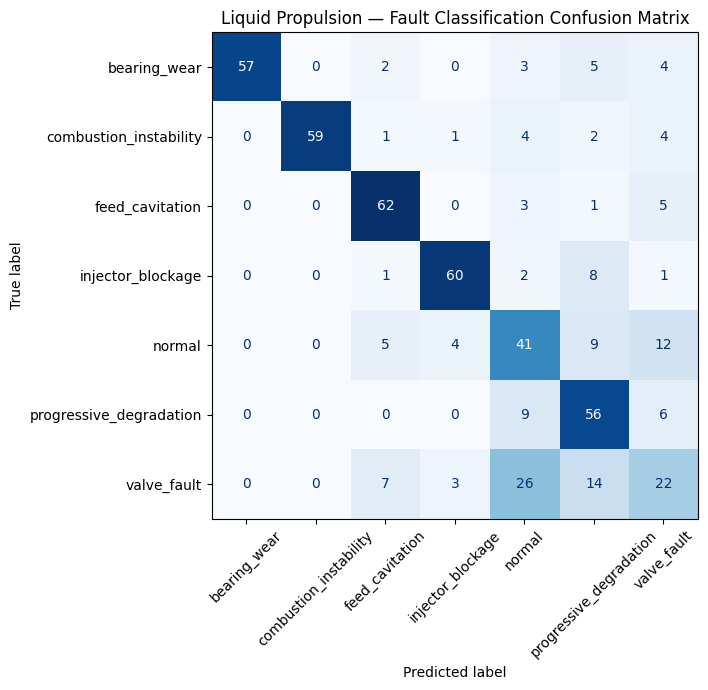

In [ ]:

fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Liquid Propulsion — Fault Classification Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


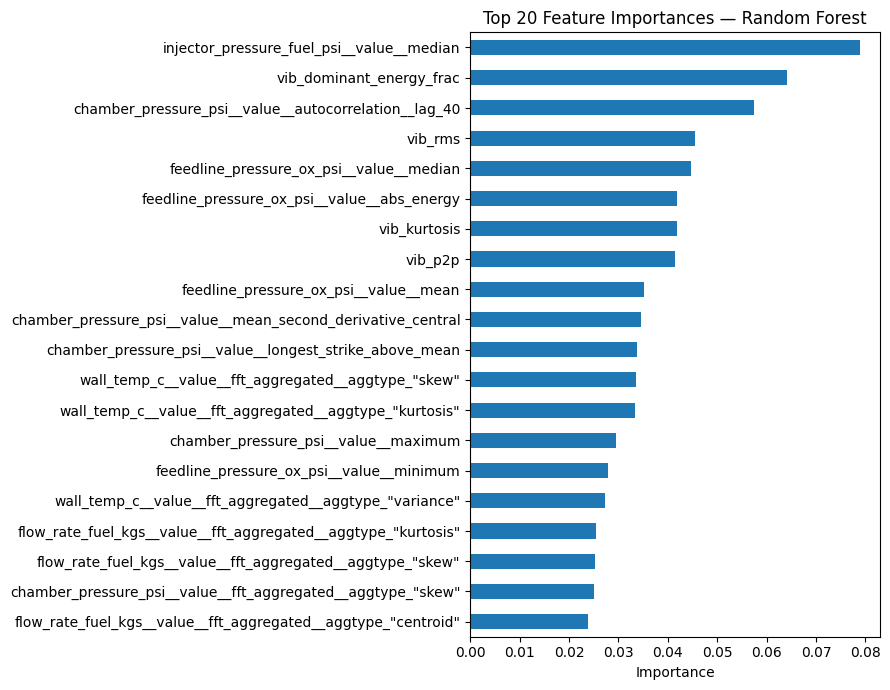

,0
injector_pressure_fuel_psi__value__median,0.078997
vib_dominant_energy_frac,0.064221
chamber_pressure_psi__value__autocorrelation__lag_40,0.057389
vib_rms,0.045567
feedline_pressure_ox_psi__value__median,0.044760
feedline_pressure_ox_psi__value__abs_energy,0.041838
vib_kurtosis,0.041792
vib_p2p,0.041353
feedline_pressure_ox_psi__value__mean,0.035232
chamber_pressure_psi__value__mean_second_derivative_central,0.034562


In [ ]:

importances = pd.Series(rf.feature_importances_, index=X_full.columns).sort_values(ascending=False)
top_n = 20
fig, ax = plt.subplots(figsize=(9, 7))
importances.head(top_n).plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title(f"Top {top_n} Feature Importances — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

importances.head(30)



## 7. Physics-based residual detector (independent second model)

Design throttle curve → expected chamber pressure. Real-time residual = actual − expected. This detector doesn't need training data at all — it's a first-principles check, and its independence from the Random Forest is exactly what your project's hybrid-AI requirement is for: two detectors that can fail in different ways.

**Important scope note:** this specific check only watches *chamber pressure*, so it's intentionally narrow — it's built to catch combustion-instability-type faults (and anything else that visibly perturbs chamber pressure vs. the commanded throttle curve), not every fault class in this subsystem. Don't expect it to have high recall standalone against classes like `bearing_wear` or `valve_fault` that don't touch chamber pressure at all — that's expected, not a bug. Its value is in the **hybrid OR** combination below, where it adds an independent, explainable catch specifically for the fault types the RF might miss or misclassify, not in replacing the RF's broader coverage.


In [ ]:

def expected_chamber_pressure(t, burn_time_s=BURN_TIME_S, p_max=P_MAX_PSI):
    '''Design throttle curve (matches the generator's baseline_channel logic
    for chamber_pressure_psi) -- in a real system, replace this with the
    actual commanded-throttle-to-pressure map from your engine's design data.'''
    ramp = np.clip(t / 0.4, 0, 1)
    tailoff = np.clip((burn_time_s - t) / 1.5, 0, 1)
    return p_max * ramp * tailoff


def physics_residual_flag(med_df, threshold_frac=0.15, sustained_fraction=0.1):
    '''Flags a window as anomalous if the chamber-pressure residual exceeds
    threshold_frac of P_MAX for at least sustained_fraction of the window
    (avoids flagging single-sample noise spikes).'''
    t = med_df["t_s"].to_numpy()
    actual = med_df["chamber_pressure_psi"].to_numpy()
    expected = expected_chamber_pressure(t)
    residual = np.abs(actual - expected) / P_MAX_PSI
    frac_over = np.mean(residual > threshold_frac)
    return int(frac_over > sustained_fraction), residual


# Evaluate the physics detector standalone, at the instance level (whole burn, not per-window,
# since the residual check is inherently a whole-signal comparison against a design curve)
physics_results = []
for instance_id, fault_type, med_df, vib_df in instances:
    flag, residual = physics_residual_flag(med_df)
    physics_results.append({
        "instance_id": instance_id, "fault_type": fault_type,
        "true_label": 0 if fault_type == "normal" else 1,
        "physics_flag": flag, "max_residual_frac": residual.max(),
    })

physics_df = pd.DataFrame(physics_results)
print("Physics-detector standalone performance (whole-burn level):")
print(classification_report(physics_df["true_label"], physics_df["physics_flag"],
                             target_names=["normal", "anomalous"]))
physics_df.groupby("fault_type")["physics_flag"].mean()


Physics-detector standalone performance (whole-burn level):
              precision    recall  f1-score   support

      normal       0.15      1.00      0.26        15
   anomalous       1.00      0.07      0.12        90

    accuracy                           0.20       105
   macro avg       0.58      0.53      0.19       105
weighted avg       0.88      0.20      0.14       105



,physics_flag
fault_type,
bearing_wear,0.0
combustion_instability,0.4
feed_cavitation,0.0
injector_blockage,0.0
normal,0.0
progressive_degradation,0.0
valve_fault,0.0



## 8. Hybrid fusion — RF + physics, combined

A window/instance is flagged anomalous if **either** detector fires. This is the simplest fusion rule and a reasonable starting point; a confidence-weighted fusion (using RF's `predict_proba` alongside the physics residual magnitude) is a natural upgrade once you have real operational data to calibrate weights against.


In [ ]:

# Roll RF's per-window predictions up to instance level (majority vote) so it's
# directly comparable to the physics detector's whole-burn-level output.
rf_pred_all = rf.predict(X_full)
rf_pred_series = pd.Series(rf_pred_all, index=X_full.index)
window_to_instance = labels_df["instance_id"]

rf_instance_vote = (
    pd.DataFrame({"instance_id": window_to_instance.loc[rf_pred_series.index],
                  "rf_pred": rf_pred_series})
    .groupby("instance_id")["rf_pred"]
    .agg(lambda s: s.value_counts().idxmax())
)

hybrid_df = physics_df.set_index("instance_id").join(rf_instance_vote)
hybrid_df["rf_flag"] = (hybrid_df["rf_pred"] != "normal").astype(int)
hybrid_df["hybrid_flag"] = ((hybrid_df["rf_flag"] == 1) | (hybrid_df["physics_flag"] == 1)).astype(int)

print("RF alone (instance-level):")
print(classification_report(hybrid_df["true_label"], hybrid_df["rf_flag"], target_names=["normal", "anomalous"]))
print("\nHybrid (RF OR physics):")
print(classification_report(hybrid_df["true_label"], hybrid_df["hybrid_flag"], target_names=["normal", "anomalous"]))

hybrid_df[["fault_type", "rf_pred", "rf_flag", "physics_flag", "hybrid_flag", "true_label"]].head(20)


RF alone (instance-level):
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        15
   anomalous       1.00      1.00      1.00        90

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105


Hybrid (RF OR physics):
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        15
   anomalous       1.00      1.00      1.00        90

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105



,fault_type,rf_pred,rf_flag,physics_flag,hybrid_flag,true_label
instance_id,,,,,,
normal_000,normal,normal,0,0,0,0
normal_001,normal,normal,0,0,0,0
normal_002,normal,normal,0,0,0,0
normal_003,normal,normal,0,0,0,0
normal_004,normal,normal,0,0,0,0
normal_005,normal,normal,0,0,0,0
normal_006,normal,normal,0,0,0,0
normal_007,normal,normal,0,0,0,0
normal_008,normal,normal,0,0,0,0


## 9. Visualize a few raw signals per fault class (sanity check)

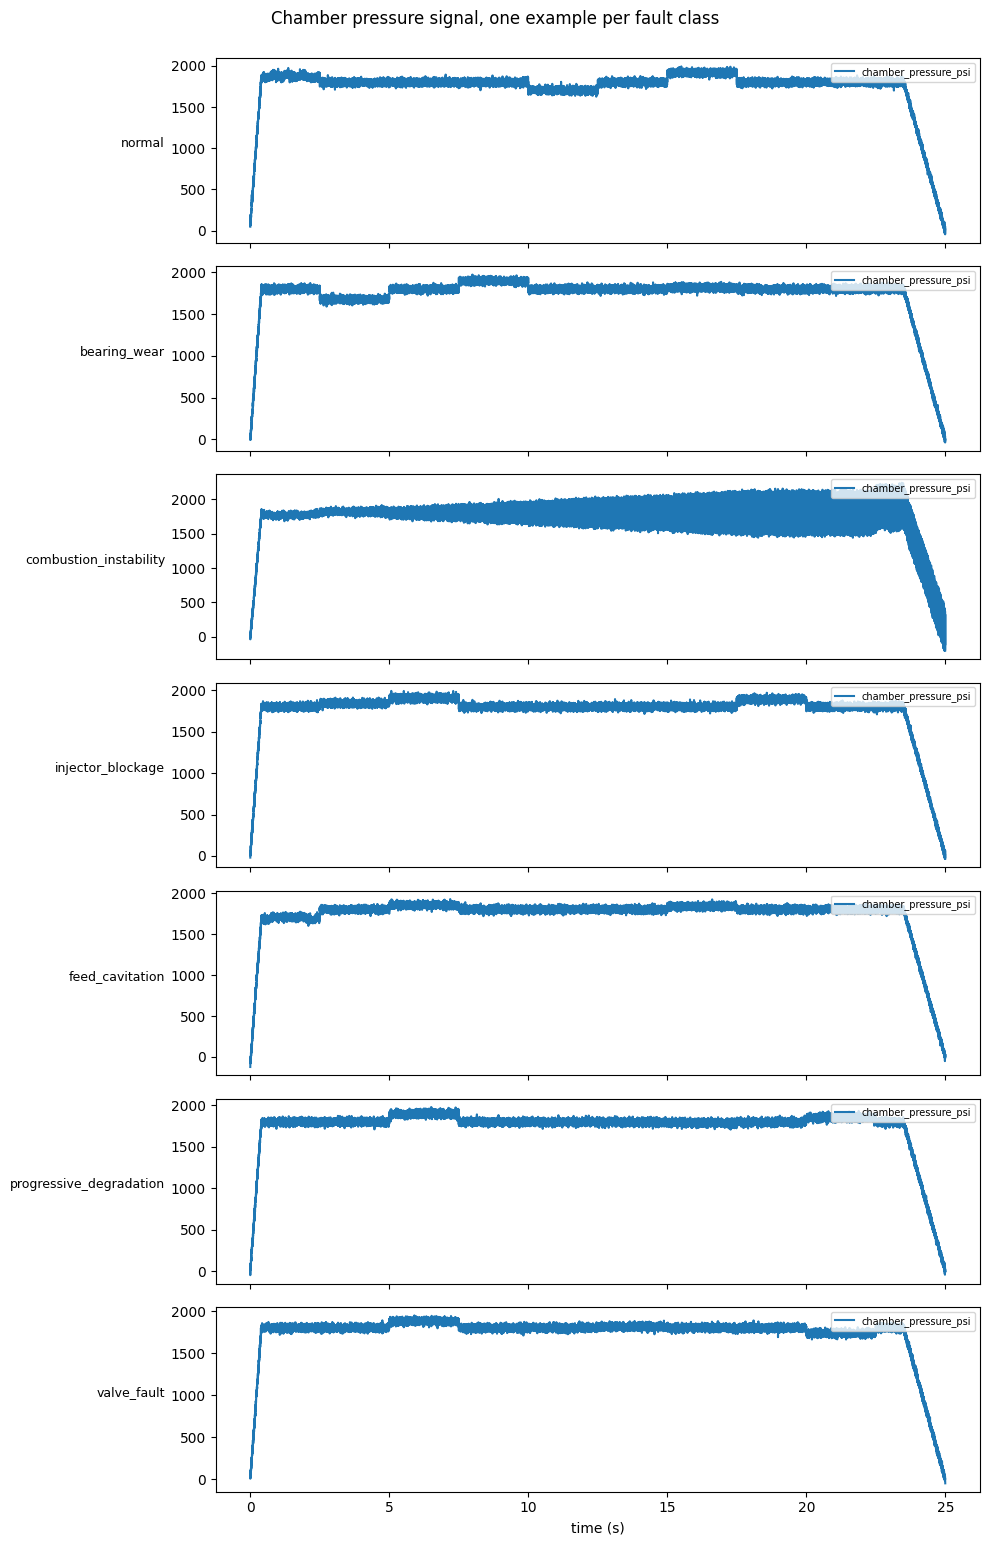

In [ ]:

fig, axes = plt.subplots(len(FAULT_TYPES), 1, figsize=(10, 2.2 * len(FAULT_TYPES)), sharex=True)
for ax, fault_type in zip(axes, FAULT_TYPES):
    example = next(d for iid, ft, d, v in instances if ft == fault_type)
    ax.plot(example["t_s"], example["chamber_pressure_psi"], label="chamber_pressure_psi")
    ax.set_ylabel(fault_type, rotation=0, ha="right", fontsize=9)
    ax.legend(loc="upper right", fontsize=7)
axes[-1].set_xlabel("time (s)")
plt.suptitle("Chamber pressure signal, one example per fault class", y=1.0)
plt.tight_layout()
plt.savefig("sample_signals.png", dpi=150)
plt.show()



## 10. Save & download the trained model

Packages the Random Forest, the selected feature list (so you extract the *same* features at inference time), and the physics-detector parameters into one artifact.


In [ ]:

import joblib
import json
import zipfile

joblib.dump(rf, "liquid_propulsion_rf_model.joblib")

with open("selected_features.json", "w") as f:
    json.dump(list(X_full.columns), f)

physics_params = {
    "P_MAX_PSI": P_MAX_PSI,
    "BURN_TIME_S": BURN_TIME_S,
    "threshold_frac": 0.15,
    "sustained_fraction": 0.1,
    "note": "expected_chamber_pressure() ramp/tailoff shape must match your REAL engine's "
            "commanded-throttle-to-pressure design curve before this is used on real telemetry -- "
            "the values here match this notebook's synthetic generator, not a real engine.",
}
with open("physics_detector_params.json", "w") as f:
    json.dump(physics_params, f, indent=2)

artifact_files = [
    "liquid_propulsion_rf_model.joblib", "selected_features.json", "physics_detector_params.json",
    "confusion_matrix.png", "feature_importance.png", "sample_signals.png",
]
with zipfile.ZipFile("liquid_propulsion_model_bundle.zip", "w") as zf:
    for fpath in artifact_files:
        zf.write(fpath)

print("Bundle contents:", artifact_files)
print("Saved: liquid_propulsion_model_bundle.zip")


Bundle contents: ['liquid_propulsion_rf_model.joblib', 'selected_features.json', 'physics_detector_params.json', 'confusion_matrix.png', 'feature_importance.png', 'sample_signals.png']
Saved: liquid_propulsion_model_bundle.zip


In [ ]:

# Downloads the bundle to your local machine (Colab-only; no-op / comment out if running elsewhere)
try:
    from google.colab import files
    files.download("liquid_propulsion_model_bundle.zip")
except ImportError:
    print("Not running in Colab -- the zip is saved locally at ./liquid_propulsion_model_bundle.zip")



## Next steps

- **Raise `N_PER_CLASS`** (try 50-100) once this runs cleanly end-to-end, for a more robust model.
- **Swap the physics detector's `expected_chamber_pressure()`** for your actual engine's real commanded-throttle-to-pressure design curve before using this on real telemetry — right now it matches this notebook's own synthetic generator, which is correct for validating the pipeline but not yet meaningful on real data.
- **Replace synthetic channels with real telemetry** as it becomes available — the feature-extraction and training cells don't need to change, only the data-generation cell.
- **Next subsystem:** re-run this same structure (generator → windowed tsfresh → BH feature selection → RF → physics/rule-based secondary check → hybrid fusion) for SRM, GNC, or whichever subsystem you want next — the pattern is identical, only the physics-check and fault classes change.


## Model Training Explanation

This notebook trains a **Random Forest Classifier** (`RandomForestClassifier` from `scikit-learn`) for fault detection.

### 1. Model Parameters (Hyperparameters)

The Random Forest model is configured with the following hyperparameters in cell `bfee7911`:

*   `n_estimators=300`: The number of decision trees in the forest. More estimators generally lead to better performance but increase computation time.
*   `max_depth=None`: Nodes are expanded until all leaves are pure or until all leaves contain less than `min_samples_split` samples. This allows the trees to grow fully.
*   `min_samples_leaf=2`: The minimum number of samples required to be at a leaf node. This helps prevent overfitting.
*   `class_weight="balanced"`: Automatically adjusts weights inversely proportional to class frequencies in the input data. This is useful for imbalanced datasets.
*   `random_state=42`: Controls the randomness of the bootstrapping of the samples and the splitting of features. Setting it to an integer ensures reproducible results.
*   `n_jobs=-1`: Uses all available CPU cores for parallel processing, speeding up training.

### 2. Data Used for Training

**a) Data Generation:**

The dataset is synthetically generated (with real-world degradation trends blended in) in cell `d92026ff`. Initially, `N_PER_CLASS` is set to `15`, creating `15` instances for each of the `7` `FAULT_TYPES`. This results in `105` unique `instance_id`s in total. Each instance simulates a rocket engine burn profile across multiple channels.

**b) Feature Extraction:**

From these `105` instances, features are extracted from

each channel within overlapping time windows (cell `f92a91d2`). This process generates a feature matrix where each row represents a time window, not an entire instance. This leads to a significantly larger number of samples for training.

*   **Original Data Points:** While there are `105` burn instances, the feature extraction process breaks each burn into multiple overlapping windows. For `N_PER_CLASS=15`, this results in `1995` data points (windows) for the feature matrix `X_full` (as seen in the output of cell `50680011`).
*   **Features (Columns):** The features are extracted using `tsfresh` (16 statistical, 8 spectral, 7 temporal features per channel) and hand-picked vibration features. After Benjamini-Hochberg significance selection (cell `50680011`), `33` features were selected for the final `X_full` matrix (`1995` samples, `33` features).
*   **Labels:** The target variable `y_multiclass` (derived from `labels_df`) contains the `fault_type` for each window (e.g., 'normal', 'bearing_wear', 'combustion_instability', etc.).

### 3. Training on the Whole Dataset

Currently, the model is trained on a split of the data (75% for training, 25% for testing) using `train_test_split` in cell `bfee7911`:

```python
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X_full, y_multiclass, X_full.index, test_size=0.25, stratify=y_multiclass, random_state=42
)
rf.fit(X_train, y_train)
```

To train the model on the entire dataset `X_full` and `y_multiclass` (without splitting it into train/test sets), you would modify this part of the code to directly fit the model on the full data. This is typically done when you are deploying a final model and have already validated its performance, or if you are performing cross-validation elsewhere.

Here's how you would modify cell `bfee7911` to train on the whole dataset:

```python
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier with the desired hyperparameters
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", random_state=42, n_jobs=-1,
)

# Train the model on the entire feature matrix (X_full) and corresponding labels (y_multiclass)
rf.fit(X_full, y_multiclass)

print("Model trained on the entire dataset.")

# Note: If you train on the entire dataset, you won't have a separate test set to evaluate
# performance with classification_report and confusion_matrix in the same way. You would
# typically use cross-validation during development or evaluate on new, unseen data.
# For demonstration, you could predict on the training data itself (which is not a good
# measure of generalization):
y_pred_full = rf.predict(X_full)
# print(classification_report(y_multiclass, y_pred_full))
```

Remember that training on the entire dataset without a separate test set will not give you an unbiased estimate of the model's generalization performance on unseen data. For robust evaluation, cross-validation or a dedicated, truly unseen test set is recommended.